# Setup - Imports

In [55]:
import pandas as pd, statsmodels.api, itertools
from sklearn.metrics import mean_squared_error

# Part 1: All Jeans Data

In [56]:
df_jeans = pd.read_excel('../data/jeans_data_full_dataset.xlsx')

In [57]:
df_jeans

,week,price,sales,special_event,se_indicator
0,1,94,259,New Year's Day,1
1,2,135,69,NaN,0
2,3,135,59,NaN,0
3,4,81,149,NaN,0
4,5,135,72,NaN,0
...,...,...,...,...,...
515,516,108,222,Black Friday,1
516,517,135,56,NaN,0
517,518,135,56,NaN,0
518,519,74,205,Christmas Eve,1


In [58]:
df_jeans.describe()

,week,price,sales,se_indicator
count,520.000000,520.000000,520.000000,520.000000
mean,260.500000,121.601923,110.923077,0.230769
std,150.255338,21.177323,69.657944,0.421731
min,1.000000,74.000000,38.000000,0.000000
25%,130.750000,108.000000,64.000000,0.000000
50%,260.500000,135.000000,74.000000,0.000000
75%,390.250000,135.000000,150.500000,0.000000
max,520.000000,135.000000,292.000000,1.000000


In [59]:
# Regression using Price and Special Event indicator as predictors
import statsmodels.api as sm

# Add constant to feature matrix which includes price and se_indicator
X_model1 = sm.add_constant(df_jeans[["price","se_indicator"]].astype("float"))

# Fit the OLS model
olsjeans1 = sm.OLS(df_jeans.sales, X_model1).fit()

In [60]:
# Add residuals to the data frame
df_jeans['residuals'] = olsjeans1.resid

## Moving Average Estimate

In [335]:
'''
• Try N = 1 to 5 and forecast estimates for weeks 6 to 520 
• Start forecast on week 6 as need 5 weeks of historical data for N=5 
• Report resultant MSE values  
• MA* = [MA(N) with optimal value of N]
'''

# Running a single MA forecast with N = 5 on weeks 6 - 520
df_jeans.residuals.rolling(5).mean()[4:519]

4       6.207433
5      -1.113605
6       5.607433
7       5.207433
8       4.012555
         ...    
514    -5.605246
515    -2.497696
516    -3.897696
517    -8.497696
518   -18.884208
Name: residuals, Length: 515, dtype: float64

In [337]:
# Try for N = [1,2,3,4,5]
for index in range(1,6):
    print([index,mean_squared_error(df_jeans.residuals[5:], 
                                    df_jeans.residuals.rolling(index).mean()[4:519])])

[1, 704.9003114780152]
[2, 532.7162183762658]
[3, 443.50546592646765]
[4, 407.83296125158586]
[5, 401.8314272214193]


Based on the N search results, we think 5 would the best estimator since it results in the lowest MSE value.

In [340]:
df_jeans.loc[5:, 'MA*'] = df_jeans.residuals.rolling(5).mean()

In [341]:
df_jeans['MA*']

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
         ...    
515    -2.497696
516    -3.897696
517    -8.497696
518   -18.884208
519    -6.381648
Name: MA*, Length: 520, dtype: float64

## Single Exponential Smoothing

In [65]:
'''
• Try alpha = 0.1 to 1 using 0.1 increments and forecast estimates for weeks 6 to 520
• Assume a burn-in period of 5 weeks
• Report resultant MSE values
• Single ES* = [Single ES(alpha) with optimal value of alpha]
'''

from statsmodels.tsa.api import ExponentialSmoothing


# Fit a single exponential smoothing model with alpha = 0.5 to test
ExponentialSmoothing(df_jeans.residuals, initialization_method='estimated').fit(smoothing_level = 0.5).predict(5,519)


5       3.044462
6      -0.232011
7      16.432348
8       1.961932
9       1.226724
         ...    
515   -15.712359
516    -0.341544
517    -6.925014
518   -10.216749
519   -29.083281
Length: 515, dtype: float64

In [66]:
# Check MSE for previous model
mean_squared_error(df_jeans.residuals[5:],
                   ExponentialSmoothing(df_jeans.residuals, initialization_method='estimated').fit(smoothing_level =0.5).predict(5,519))

461.79053421804787

In [343]:
import numpy as np

# Test for alpha from 0 - 1 with 0.1 increments
for alpha in np.arange(0.1, 1.1, 0.1):
    print([alpha,
           mean_squared_error(df_jeans.residuals[5:],
                ExponentialSmoothing(df_jeans.residuals,
                initialization_method='estimated').fit(smoothing_level = alpha).predict(5,519))])

[np.float64(0.1), 359.7118372640724]
[np.float64(0.2), 379.98876921968656]
[np.float64(0.30000000000000004), 403.24331028301447]
[np.float64(0.4), 430.38072217757764]
[np.float64(0.5), 461.79053421804787]
[np.float64(0.6000000000000001), 497.86612296473254]
[np.float64(0.7000000000000001), 539.1741285197776]
[np.float64(0.8), 586.5368374026198]
[np.float64(0.9), 641.1666352111365]
[np.float64(1.0), 704.9003114780152]


Based on fitting the model with alpha values between 0 and 1 with 0.1 increments, alpha = 0.1 appears to have the best results for lowering MSE.

In [344]:
# Add SE* to data frame
df_jeans['Single ES*'] = ExponentialSmoothing(df_jeans.residuals, initialization_method='estimated').fit(smoothing_level = 0.1).predict(5,519)

In [345]:
df_jeans['Single ES*']

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
         ...   
515   -5.296445
516   -3.263873
517   -4.288334
518   -5.210349
519   -9.484296
Name: Single ES*, Length: 520, dtype: float64

## Comparing MA and SES

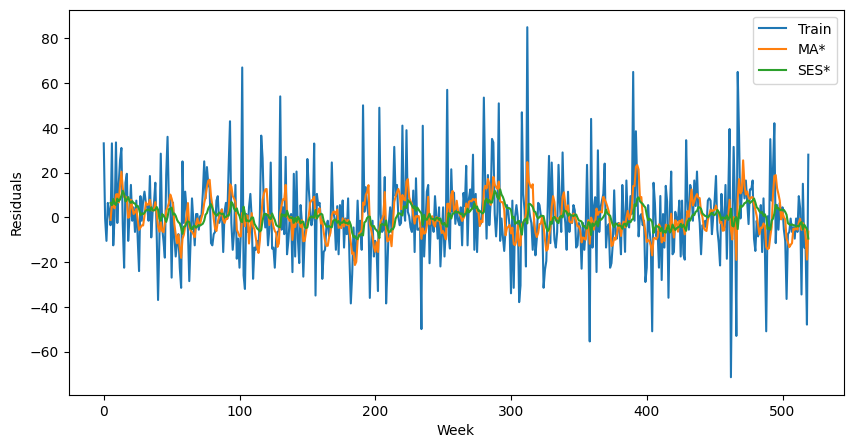

In [346]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df_jeans.residuals[:520], label='Train')
plt.plot(df_jeans['MA*'][5:], label='MA*')
plt.plot(df_jeans['Single ES*'][5:], label='SES*')
plt.legend(loc='best')
plt.xlabel('Week')
plt.ylabel('Residuals')
plt.show()


In [349]:
optimal_ma_mse = mean_squared_error(df_jeans.residuals[5:], df_jeans.residuals.rolling(index).mean()[4:519])
optimal_ses_mse = mean_squared_error(df_jeans.residuals[5:],ExponentialSmoothing(df_jeans.residuals, initialization_method='estimated').fit(smoothing_level = 0.1).predict(5,519))

In [351]:
print(f'The MSE for the optimal value of N for the Moving Average (N = 5) = {optimal_ma_mse}')
print(f'The MSE for the optimal value of Alpha for SES (alpha = 0.1) = {optimal_ses_mse}')

The MSE for the optimal value of N for the Moving Average (N = 5) = 401.8314272214193
The MSE for the optimal value of Alpha for SES (alpha = 0.1) = 359.7118372640724


Looking at both model's actual MSE when predicting residuals for weeks 6 - 520 as well as how they visually fit on the graph when plotted against the residuals, my recommendation would be to use the Single Exponential Smoothing model on the data. After optimizing the parameters and finding the best values for N and alpha and predicting for weeks 6-520, we ended up with MSE values for both models.

The MA model had an MSE of 401 while the SES model had an MSE of 359. This indicates that for the training data we have (520 weeks of jean sales) the SES model did a better job of forecasting the value of the residuals so we can have some trust that going forward it will continue to do well given our current knowledge.

# Part 2: Non-Stationary Series with Trend

## a: Test for non-stationary data

* Using the Augmented Dickey-Fuller test, provide your conclusion on the nature of the data based on patterns of the Bitcoin prices over time

In [182]:
df_bitcoin = pd.read_excel('../data/bitcoin_data_2023_2024.xlsx')

In [183]:
df_bitcoin

,date,close_price
0,2023-03-22,27307.437500
1,2023-03-23,28333.972656
2,2023-03-24,27493.285156
3,2023-03-25,27494.707031
4,2023-03-26,27994.330078
...,...,...
361,2024-03-17,68390.625000
362,2024-03-18,67548.593750
363,2024-03-19,61912.773438
364,2024-03-20,67913.671875


<Axes: xlabel='date'>

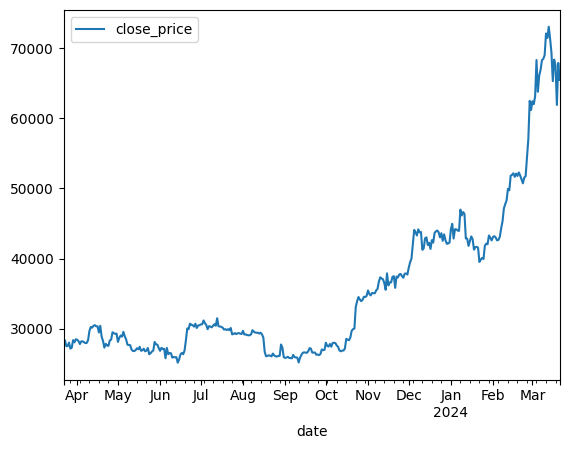

In [184]:
df_bitcoin.plot(kind='line', x='date', y='close_price')

In [ ]:
# Dickey-Fuller unit root test
# p-value > 0.05 -> not rejecting H1 -> nonstationary
from statsmodels.tsa.stattools import adfuller

ad_result = adfuller(df_bitcoin.close_price)

print('ADF Statistic: %f' % ad_result[0])
print('p-value: %f' % ad_result[1])

ADF Statistic: 1.152174
p-value: 0.995638


After running our Dickey-Fuller statistic test, we see that the resultant p-value is 0.995, which is much higher than our p-value of 0.05 for statistical significance with 95% confidence, so we cannot reject the null hypothesis because we don't have statistical proof that the data is stationary. Since we cannot reject H1, we can assume the data is non-stationary.

Since we believe now it is non-stationary, we can use DES methods for prediction to account for the general upward trend.

## b: Double Exponential Smoothing (DES) estimations



In [186]:
'''
• Provided that your test for non-stationarity was supported, forecast estimates by 
fitting a DES model
• Try alpha and beta from 0 to 1 with 0.05 increments 
• Use the first 265 days as training sample 
• Assume a burn-in period of 10 days 
• Calculate training sample MSE for days 11 to 265 
• Forecast for the last 100 days 
• DES* = [optimal DES(alpha,beta) with optimal combination of alpha and beta] 
• Report resultant MSE values, both for process of forecasting training and test data. 
Provide a conclusion on whether the DES* performs better on the train or test data. 
• Generate plot with Bitcoin prices and DES* forecasts. Explain what is represented in 
the plot. Simply showing output of running code does not suffice as an explanation, 
clearly state what is shown in the plot in your own words! 
'''

'\n• Provided that your test for non-stationarity was supported, forecast estimates by \nfitting a DES model\n• Try alpha and beta from 0 to 1 with 0.05 increments \n• Use the first 265 days as training sample \n• Assume a burn-in period of 10 days \n• Calculate training sample MSE for days 11 to 265 \n• Forecast for the last 100 days \n• DES* = [optimal DES(alpha,beta) with optimal combination of alpha and beta] \n• Report resultant MSE values, both for process of forecasting training and test data. \nProvide a conclusion on whether the DES* performs better on the train or test data. \n• Generate plot with Bitcoin prices and DES* forecasts. Explain what is represented in \nthe plot. Simply showing output of running code does not suffice as an explanation, \nclearly state what is shown in the plot in your own words! \n'

In [187]:
df_bitcoin

,date,close_price
0,2023-03-22,27307.437500
1,2023-03-23,28333.972656
2,2023-03-24,27493.285156
3,2023-03-25,27494.707031
4,2023-03-26,27994.330078
...,...,...
361,2024-03-17,68390.625000
362,2024-03-18,67548.593750
363,2024-03-19,61912.773438
364,2024-03-20,67913.671875


In [ ]:
df_bitcoin[10:265]

,date,close_price
0,2023-03-22,27307.437500
1,2023-03-23,28333.972656
2,2023-03-24,27493.285156
3,2023-03-25,27494.707031
4,2023-03-26,27994.330078
...,...,...
260,2023-12-07,43292.664063
261,2023-12-08,44166.601563
262,2023-12-09,43725.984375
263,2023-12-10,43779.699219


In [165]:
# Fit a single DES model on bitcoin pricing to test
ExponentialSmoothing(df_bitcoin.close_price[:265],
    trend="add",
    initialization_method='estimated').fit(smoothing_level = 0.3,
                                        smoothing_trend = 0.5).predict(266, 365)

266    43451.198734
267    43075.755763
268    42700.312793
269    42324.869822
270    41949.426851
           ...     
361     7784.116525
362     7408.673554
363     7033.230584
364     6657.787613
365     6282.344642
Length: 100, dtype: float64

In [166]:
df_bitcoin

,date,close_price
0,2023-03-22,27307.437500
1,2023-03-23,28333.972656
2,2023-03-24,27493.285156
3,2023-03-25,27494.707031
4,2023-03-26,27994.330078
...,...,...
361,2024-03-17,68390.625000
362,2024-03-18,67548.593750
363,2024-03-19,61912.773438
364,2024-03-20,67913.671875


In [369]:
# Function for alpha and beta as input and produces the traning sample MSE
from sklearn.metrics import mean_squared_error
import numpy as np

def TrainingSampleMSE(alpha,beta):
    return mean_squared_error(df_bitcoin.close_price[10:266],
                ExponentialSmoothing(df_bitcoin.close_price[:266],trend="add", initialization_method='estimated').fit(smoothing_level = alpha,smoothing_trend = beta).predict(10, 265))

In [357]:
# Function for grid search
from itertools import product
def expand_grid(dictionary):
   return pd.DataFrame([row for row in product(*dictionary.values())], 
                       columns=dictionary.keys())

In [370]:
# Define the alpha and beta values to try as a dictionary
dictionary = {'alpha': np.arange(0.0, 1.05, 0.05), 
              'beta': np.arange(0.0, 1.05, 0.05)}

# Run the grid search
des_results = expand_grid(dictionary)

In [371]:
# Add a column called mse, as a place holder for putting in the MSE results later
des_results["mse"] = np.repeat(0,len(des_results))

In [372]:
des_results

,alpha,beta,mse
0,0.0,0.00,0
1,0.0,0.05,0
2,0.0,0.10,0
3,0.0,0.15,0
4,0.0,0.20,0
...,...,...,...
436,1.0,0.80,0
437,1.0,0.85,0
438,1.0,0.90,0
439,1.0,0.95,0


In [375]:
# Run the training loop to find best alpha/beta combination
for alpha in np.arange(0.00, 1.05, 0.05):
    for beta in np.arange(0.00, 1.05, 0.05):
       curr_mse = TrainingSampleMSE(alpha,beta)
       des_results.loc[(des_results["alpha"] == alpha) & (des_results["beta"] == beta),"mse"] = curr_mse
       print(f'Alpha = {alpha} + Beta = {beta} MSE = {curr_mse}')

Alpha = 0.0 + Beta = 0.0 MSE = 11904914.572627047
Alpha = 0.0 + Beta = 0.05 MSE = 11904854.125597138
Alpha = 0.0 + Beta = 0.1 MSE = 11904785.914651865
Alpha = 0.0 + Beta = 0.15000000000000002 MSE = 11904816.99006884
Alpha = 0.0 + Beta = 0.2 MSE = 11904785.629028978
Alpha = 0.0 + Beta = 0.25 MSE = 11904914.572627047
Alpha = 0.0 + Beta = 0.30000000000000004 MSE = 11904765.250402706
Alpha = 0.0 + Beta = 0.35000000000000003 MSE = 11904785.00001669
Alpha = 0.0 + Beta = 0.4 MSE = 11904826.237153606
Alpha = 0.0 + Beta = 0.45 MSE = 11904866.795863846
Alpha = 0.0 + Beta = 0.5 MSE = 11905781.330781125
Alpha = 0.0 + Beta = 0.55 MSE = 11904769.845809877
Alpha = 0.0 + Beta = 0.6000000000000001 MSE = 11904975.50817139
Alpha = 0.0 + Beta = 0.65 MSE = 11905781.33078539
Alpha = 0.0 + Beta = 0.7000000000000001 MSE = 11904926.46576899
Alpha = 0.0 + Beta = 0.75 MSE = 11905781.330781125
Alpha = 0.0 + Beta = 0.8 MSE = 11905781.330781125
Alpha = 0.0 + Beta = 0.8500000000000001 MSE = 11905781.330781125
Alpha 

/Users/gregoryknapp/Code/BU/BU-SP2026-BA875-Assignments/.venv/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/gregoryknapp/Code/BU/BU-SP2026-BA875-Assignments/.venv/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/gregoryknapp/Code/BU/BU-SP2026-BA875-Assignments/.venv/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/gregoryknapp/Code/BU/BU-SP2026-BA875-Assignments/.venv/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/gregoryknapp/Code/BU/BU-SP2026-BA875-Assignments/.venv/lib/python3.10/site-packages/statsmodels/tsa/holtw

In [376]:
# Check for best alpha/beta
des_results.sort_values("mse").head(10)

,alpha,beta,mse
399,0.95,0.00,401731.191719
420,1.00,0.00,402518.501622
378,0.90,0.00,403372.614593
357,0.85,0.00,407553.018586
400,0.95,0.05,408445.681557
379,0.90,0.05,408780.840262
421,1.00,0.05,410672.808275
358,0.85,0.05,411754.976848
336,0.80,0.00,414467.094131
380,0.90,0.10,417358.631181


Based on the results of the grid search it appears that the training sample MSE was the lowest when alpha = 0.95 and beta = 0.00, resulting in an MSE of 401731.19

In [378]:
# Run the DES model and save the results to the original data frame
df_bitcoin.loc[df_bitcoin.index[266:], 'DES*'] = ExponentialSmoothing(df_bitcoin.close_price[:266],trend="add", initialization_method='estimated').fit(smoothing_level = 0.95,smoothing_trend = 0.00).forecast(100)

In [381]:
# Calculate Test MSE
mean_squared_error(df_bitcoin.close_price[266:],df_bitcoin['DES*'][266:])

110490202.24691266

### Analysis of MSE Results

**Train MSE (Days 1 - 255):** 2786.13 - After doing the grid search and finding that alpha = 1 and beta = 0 had the best results for minimizing the errors in our forecast in the training data, we had a final training MSE of 2786.13, which is quite good. Our predictor is in large units (peak Bitcoin price in our training data approached 50,000) so large errors would appear even larger due to the nature of MSE (squared error). So it appears that at least for the training data, we were able to get fairly good performance, enough to have a good sense of where it is going.

**Test MSE (Days 266 - 366):** 111600822.12 - Unfortunately, our test MSE data was not as good as our training MSE. This is typical, as performance in a hold out set should never be better than the training data, which we are able to optimize and minimize the error in. However, the error here is quite extremely large. As mentioned in the training MSE section, MSE will cause the error amount to spike rapidly due to the squared residuals in the summation of the errors combined with the large units the output variable price already has. Still, this MSE is quite high, so it will be helpful to look at the graph and see the comparison between the projections and the actual price to determine what happened to cause such a difference.

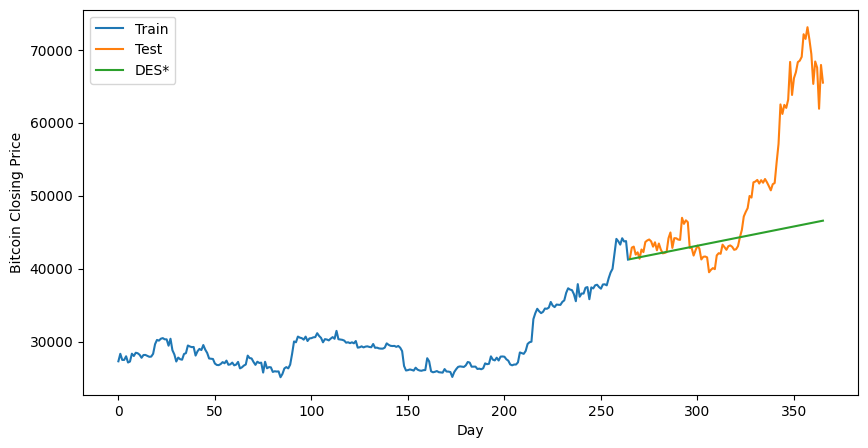

In [200]:
# Plot train vs. test with forecast line
plt.figure(figsize=(10,5))
plt.plot(df_bitcoin.close_price[:265], label='Train')
plt.plot(df_bitcoin.close_price[265:], label='Test')
plt.plot(df_bitcoin['DES*'][265:], label='DES*')
plt.legend(loc='best')
plt.xlabel('Day')
plt.ylabel('Bitcoin Closing Price')
plt.show()

### Visual Analysis of DES results on Bitcoing Closing Price Forecast

After overlaying the forecasted price against the hold out price data, the extremely high test MSE cause becomes much more clear. For the first 50 or so days of the hold out test data, the forecast actually seems to hold pretty close, at least as a smoothed predictor of the somewhat up and down price data. It captures the general upwards trend and even until approximately day 315/320 feels like a reasonable forecast with how it lines up. Past there however, it fails to keep up with the extreme spike in the price that appears over the final days of the test data.

Doing a bit of historical reading for context, there appears to be 2 main reasons for this massive spike: the approval of Bitcoin ETFs by the SEC in January 2024 and the Bitcoin halving event in April 2024. The SEC ruling allowed for Bitcoin traded products to trade on major public stock exchanges, which had a bullish effect on the price. Additionally, the halving event (without getting too technical in the underlying mechanics of it) results in increased scarcity of Bitcoin by reducing the price reward of each new block mined, which as a result drives up price signficantly. These two events happening in the same general time frame represent external events that are difficult to account for with a simple forecasting model like this, and that is reflected in both the test MSE increase and the visual representation of the actual price spike over the stable conservative prediction.

# Part 3 - De-Seasonalizing Data and Forecasting Airline Data

Load and clean up the data for easy use 

In [288]:
df_airline = pd.read_excel("../data/airline_data.xlsx")
df_airline

,Unnamed: 0,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,January,64.40,65.28,69.77,72.68,72.30,72.95,72.82,74.89,76.55,78.02,78.89
1,February,68.10,68.60,71.58,76.07,75.71,75.91,75.28,77.35,77.92,78.90,80.77
2,March,72.43,75.13,79.58,81.31,81.57,82.19,81.08,83.39,82.70,84.43,84.99
3,April,72.13,76.17,76.64,81.34,81.38,80.09,82.10,82.55,82.13,83.61,82.81
4,May,73.98,74.41,77.52,80.39,81.27,81.34,81.32,82.51,84.58,84.45,84.84
5,June,78.58,80.72,82.27,84.56,86.24,84.24,85.37,86.32,85.98,86.62,86.98
6,July,80.98,82.20,83.94,84.95,86.24,84.11,87.09,86.90,87.14,86.83,86.46
7,August,78.74,78.74,80.34,80.90,84.89,83.35,84.97,85.20,85.59,86.61,85.53
8,September,66.93,70.39,74.12,73.78,75.61,76.07,79.42,79.81,81.82,80.64,80.90
9,October,71.47,74.23,75.94,77.50,78.45,79.76,82.22,83.32,83.63,84.23,82.77


In [289]:
# Remove unnamed index
df_airline = df_airline.reset_index()

# Pivot longer
df_airline = pd.melt(df_airline, id_vars=['index'])

# Fix names
df_airline = df_airline.iloc[12: , :]
df_airline.columns = ["month","year","load"]

In [290]:
df_airline

,month,year,load
12,0,2003,64.4
13,1,2003,68.1
14,2,2003,72.43
15,3,2003,72.13
16,4,2003,73.98
...,...,...,...
139,7,2013,85.53
140,8,2013,80.9
141,9,2013,82.77
142,10,2013,NaN


## a. De-seasonalize the historical data  
 
• The company provided you with the raw data, but have reported that it needs to be adjusted for seasonality before being forecasted. Thus, as a first step, perform the steps to de-seasonalize the data and report the resultant dataset 

In [291]:
# 4-steps for De-seasonalizing the data

# STEP 1: take the sample average
df_airline["avg"] = df_airline.load.dropna().mean()

df_airline.avg

12     79.444692
13     79.444692
14     79.444692
15     79.444692
16     79.444692
         ...    
139    79.444692
140    79.444692
141    79.444692
142    79.444692
143    79.444692
Name: avg, Length: 132, dtype: float64

In [292]:
# STEP 2: take the monthly average
df_airline["month_avg"] = pd.to_numeric(df_airline['load']).groupby(df_airline['month']).transform("mean")

df_airline.month_avg

12     72.595455
13     75.108182
14     80.800000
15     80.086364
16     80.600909
         ...    
139    83.169091
140    76.317273
141    79.410909
142    77.834000
143    77.578000
Name: month_avg, Length: 132, dtype: float64

In [293]:
# STEP 3: calculate the seasonal factor
df_airline["season_factor"] = df_airline.month_avg / df_airline.avg

df_airline.season_factor

12     0.913786
13     0.945415
14     1.017060
15     1.008077
16     1.014554
         ...   
139    1.046880
140    0.960634
141    0.999575
142    0.979726
143    0.976503
Name: season_factor, Length: 132, dtype: float64

In [294]:
# STEP 4: save the de-sesonalized series
df_airline["de_load"] = df_airline.load / df_airline.season_factor
df_airline['de_load'] = df_airline.de_load.astype("float64")
df_airline.head(24)

,month,year,load,avg,month_avg,season_factor,de_load
12,0,2003,64.4,79.444692,72.595455,0.913786,70.476013
13,1,2003,68.1,79.444692,75.108182,0.945415,72.031880
14,2,2003,72.43,79.444692,80.800000,1.017060,71.215087
15,3,2003,72.13,79.444692,80.086364,1.008077,71.552077
16,4,2003,73.98,79.444692,80.600909,1.014554,72.918760
17,5,2003,78.58,79.444692,84.352727,1.061779,74.007849
18,6,2003,80.98,79.444692,85.167273,1.072032,75.538772
19,7,2003,78.74,79.444692,83.169091,1.046880,75.213941
20,8,2003,66.93,79.444692,76.317273,0.960634,69.672737
21,9,2003,71.47,79.444692,79.410909,0.999575,71.500405


<Axes: >

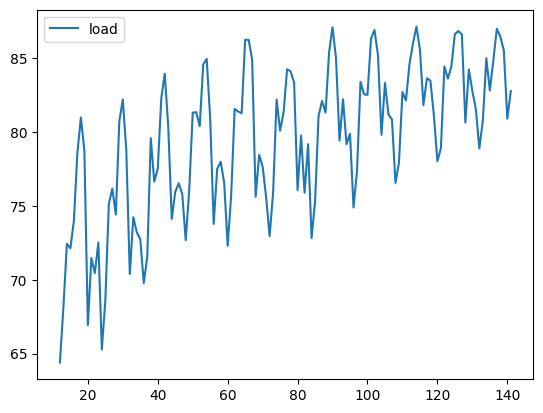

In [296]:
# Pre-cleaning load data
df_airline.plot(kind='line', y='load')

<Axes: >

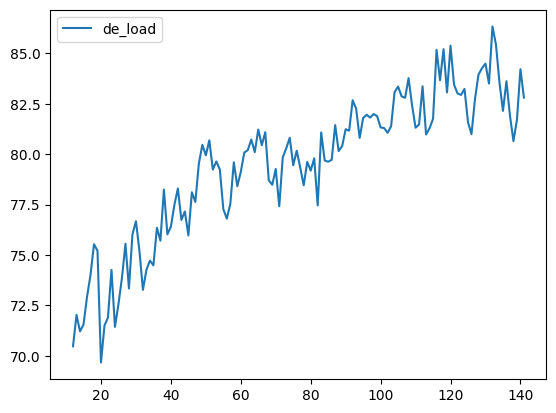

In [297]:
# De-Seasonalized load data
df_airline.plot(kind='line', y='de_load')

# b. Test for non-stationarity

• Using the Augmented Dickey-Fuller test (ADF test), provide your conclusion on the nature of the data based on patterns of the (de-seasonalized) airline load factor data over time
• Based on your conclusion from the ADF test, evaluate the appropriate time series forecasting method(s) from those discussed in class. DO NOT arbitrarily select one or more of the forecasting methods. Be clear on the reason for selecting any appropriate forecasting methods AND the basis for determining the most accurate forecast method to move forward with in the proceeding steps.
• Use the most accurate forecast method to forecast the last two months in December 2013
• Assume no burn-in period required
• Report resultant MSE values from any forecasting method that was used
• Report forecast of the last two months in December 2013 and make sure to scale back by the seasonal factor for final forecast. Explain the meaning of the reported forecast.

Simply showing output of running code does not suffice as an explanation, clearly state what the forecast tells us in your own words!

### ADF Test on de-seasonalized data

In [298]:
df_airline.de_load

12     70.476013
13     72.031880
14     71.215087
15     71.552077
16     72.918760
         ...    
139    81.699877
140    84.215216
141    82.805212
142          NaN
143          NaN
Name: de_load, Length: 132, dtype: float64

In [299]:
ad_result = adfuller(df_airline.de_load[:-2]) # Exclude the final 2 months since they have not been forecasted yet

print('ADF Statistic: %f' % ad_result[0])
print('p-value: %f' % ad_result[1])

ADF Statistic: -3.194312
p-value: 0.020316


Based on the results of the of the AD Fuller test, I believe the data is stationary, so we should only test forecasting models that match that. I reached this conclusion because of the p-value from the AD test, which was 0.02. For 95% confidence, the threshold we are looking to to reject our null hypothesis that the data is non-stationary, we want to see a p-value<0.05, which did happen in this case. Due to this, we can reject the null hypothesis that the data is non-stationary and we know that at least for this sample of data, it should be treated as stationary.

This means that forecasting models that include trend should not be evaluated here since that does not make sense with stationary data, so DES models will be ruled out from consideration. This leaves us with SES and Moving Average models to fit on this data.

### Airline Data- Moving Average Forecast

In [300]:
df_airline.de_load[:-2].rolling(1).mean()

12     70.476013
13     72.031880
14     71.215087
15     71.552077
16     72.918760
         ...    
137    81.919098
138    80.650558
139    81.699877
140    84.215216
141    82.805212
Name: de_load, Length: 130, dtype: float64

In [383]:
df_airline.de_load[5:130]

17     74.007849
18     75.538772
19     75.213941
20     69.672737
21     71.500405
         ...    
137    81.919098
138    80.650558
139    81.699877
140    84.215216
141    82.805212
Name: de_load, Length: 125, dtype: float64

In [384]:
df_airline.de_load.rolling(index).mean()[4:129]

16     71.638763
17     72.345131
18     73.046509
19     73.846280
20     73.470412
         ...    
136    84.220083
137    83.337279
138    82.380709
139    82.007803
140    82.421545
Name: de_load, Length: 125, dtype: float64

In [ ]:
# Try for N = [1,2,3,4,5]
for index in range(1,6):
    print([index,mean_squared_error(df_airline.de_load[5:130],
                                    df_airline.de_load.rolling(index).mean()[4:129])])

[1, 2.122028293186414]
[2, 1.9396693859812697]
[3, 2.0464728995430366]
[4, 1.999502009897671]
[5, 2.203803784046814]


It looks like the rolling average prediction performs the best when used with just N = 2 when comparing by MSE. When N = 2, the MSE was 1.93 Before we predict for the last 2 months, I want to compare it with the performance of the SES model to see which does better on the "training" data (all rows except the final 2).

In [390]:
df_airline.loc[130:,'ma'] = df_airline['de_load'][:130].rolling(2).mean()[:-1]

In [391]:
df_airline

,month,year,load,avg,month_avg,season_factor,de_load,ma
12,0,2003,64.400000,79.444692,72.595455,0.913786,70.476013,NaN
13,1,2003,68.100000,79.444692,75.108182,0.945415,72.031880,NaN
14,2,2003,72.430000,79.444692,80.800000,1.017060,71.215087,NaN
15,3,2003,72.130000,79.444692,80.086364,1.008077,71.552077,NaN
16,4,2003,73.980000,79.444692,80.600909,1.014554,72.918760,NaN
...,...,...,...,...,...,...,...,...
139,7,2013,85.530000,79.444692,83.169091,1.046880,81.699877,81.175218
140,8,2013,80.900000,79.444692,76.317273,0.960634,84.215216,82.957547
141,9,2013,82.770000,79.444692,79.410909,0.999575,82.805212,NaN
142,10,2013,81.817096,79.444692,77.834000,0.979726,83.510214,NaN


### Airline Data - SES Forecast

In [304]:
df_airline

,month,year,load,avg,month_avg,season_factor,de_load
12,0,2003,64.4,79.444692,72.595455,0.913786,70.476013
13,1,2003,68.1,79.444692,75.108182,0.945415,72.031880
14,2,2003,72.43,79.444692,80.800000,1.017060,71.215087
15,3,2003,72.13,79.444692,80.086364,1.008077,71.552077
16,4,2003,73.98,79.444692,80.600909,1.014554,72.918760
...,...,...,...,...,...,...,...
139,7,2013,85.53,79.444692,83.169091,1.046880,81.699877
140,8,2013,80.9,79.444692,76.317273,0.960634,84.215216
141,9,2013,82.77,79.444692,79.410909,0.999575,82.805212
142,10,2013,NaN,79.444692,77.834000,0.979726,NaN


In [307]:
df_airline

,month,year,load,avg,month_avg,season_factor,de_load
12,0,2003,64.4,79.444692,72.595455,0.913786,70.476013
13,1,2003,68.1,79.444692,75.108182,0.945415,72.031880
14,2,2003,72.43,79.444692,80.800000,1.017060,71.215087
15,3,2003,72.13,79.444692,80.086364,1.008077,71.552077
16,4,2003,73.98,79.444692,80.600909,1.014554,72.918760
...,...,...,...,...,...,...,...
139,7,2013,85.53,79.444692,83.169091,1.046880,81.699877
140,8,2013,80.9,79.444692,76.317273,0.960634,84.215216
141,9,2013,82.77,79.444692,79.410909,0.999575,82.805212
142,10,2013,NaN,79.444692,77.834000,0.979726,NaN


In [308]:
ExponentialSmoothing(df_airline['de_load'], initialization_method='estimated').fit(smoothing_level = 0.5).predict(0,129)

/Users/gregoryknapp/Code/BU/BU-SP2026-BA875-Assignments/.venv/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


12     71.554453
13     71.015233
14     71.523557
15     71.369322
16     71.460699
         ...    
137    83.449680
138    82.684389
139    81.667474
140    81.683675
141    82.949446
Length: 130, dtype: float64

In [385]:
import numpy as np

# Test for alpha from 0 - 1 with 0.1 increments
for alpha in np.arange(0.1, 1.1, 0.1):
    print([alpha,
           mean_squared_error(df_airline.de_load[:-2],ExponentialSmoothing(df_airline.de_load, initialization_method='estimated').fit(smoothing_level = alpha).predict(0,129))])

[np.float64(0.1), 2.692611451203892]
[np.float64(0.2), 2.014251547864447]
[np.float64(0.30000000000000004), 1.860723749750682]
[np.float64(0.4), 1.7978617819265135]
[np.float64(0.5), 1.7731644358160334]
[np.float64(0.6000000000000001), 1.7784138463803603]
[np.float64(0.7000000000000001), 1.811473320809394]
[np.float64(0.8), 1.8714705618595775]
[np.float64(0.9), 1.9593665610053126]
[np.float64(1.0), 2.0794061077383326]


For the SES forecast on the training data, it looks like when alpha = 0.5 we had a minimum MSE of 1.773, which is quite good just taken in isolation. However, we need to now compare the Moving Average results to the SES results to see which model is best suited for making a final prediction.

### Airline data - Making a final prediction

**MA Training MSE (N = 2):** 0.52
**SES Training MSE (alpha = 0.5):** 1.77

While MSE is not the only metric we can use, it is a helpful way to directly compare the forecasts made on data that we already have (i.e. training data). When looking at these two models, although they both performed well generally speaking, it looks like the Moving Average model with N = 2 did slightly better at predicting the training data, so we will go with that for making a final predictions.

While in this case, it is not much more work to predict with both models and see, in the real world this may not always be feasible. This data set is very small and only covers <150 rows. Some real world datasets span millions and millions of rows, which increase the compute cost and time of training a model. There are consequences for the decisions made when picking a model, so we have to rely on metrics to inform the decision making and reduce the number of models we train and put into production, otherwise we may not be able to support the cost of upkeep and usage.

In [312]:
df_airline

,month,year,load,avg,month_avg,season_factor,de_load
12,0,2003,64.4,79.444692,72.595455,0.913786,70.476013
13,1,2003,68.1,79.444692,75.108182,0.945415,72.031880
14,2,2003,72.43,79.444692,80.800000,1.017060,71.215087
15,3,2003,72.13,79.444692,80.086364,1.008077,71.552077
16,4,2003,73.98,79.444692,80.600909,1.014554,72.918760
...,...,...,...,...,...,...,...
139,7,2013,85.53,79.444692,83.169091,1.046880,81.699877
140,8,2013,80.9,79.444692,76.317273,0.960634,84.215216
141,9,2013,82.77,79.444692,79.410909,0.999575,82.805212
142,10,2013,NaN,79.444692,77.834000,0.979726,NaN


In [ ]:
# Predict the values for the final two months of the airline data using the Moving Average model with N = 2
df_airline.de_load.rolling(2).mean()

12           NaN
13     71.253946
14     71.623484
15     71.383582
16     72.235418
         ...    
139    81.175218
140    82.957547
141    83.510214
142          NaN
143          NaN
Name: de_load, Length: 132, dtype: float64

In [325]:
# Calculate the moving average and assign the values into the final months
df_airline.loc[142:, 'de_load'] = df_airline.de_load[:-2].rolling(2).mean().iloc[-1]

In [326]:
# Print the estimated values
print(f'Estimated de-seasonalized load for November and December: {df_airline.loc[142, "de_load"]}')

Estimated de-seasonalized load for November and December: 83.51021412828192


In [330]:
# Scale the de_load back to the seasonal factor
df_airline.load = df_airline.de_load * df_airline.season_factor

In [331]:
# Print the final two rows of the dataframe
df_airline.tail(5)

,month,year,load,avg,month_avg,season_factor,de_load
139,7,2013,85.530000,79.444692,83.169091,1.046880,81.699877
140,8,2013,80.900000,79.444692,76.317273,0.960634,84.215216
141,9,2013,82.770000,79.444692,79.410909,0.999575,82.805212
142,10,2013,81.817096,79.444692,77.834000,0.979726,83.510214
143,11,2013,81.547995,79.444692,77.578000,0.976503,83.510214


<Axes: >

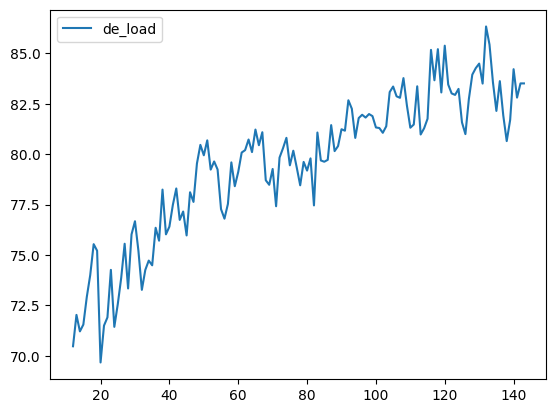

In [ ]:
# De-Seasonalized load data with new predictions at the end
df_airline.plot(kind='line', y='de_load')

<Axes: >

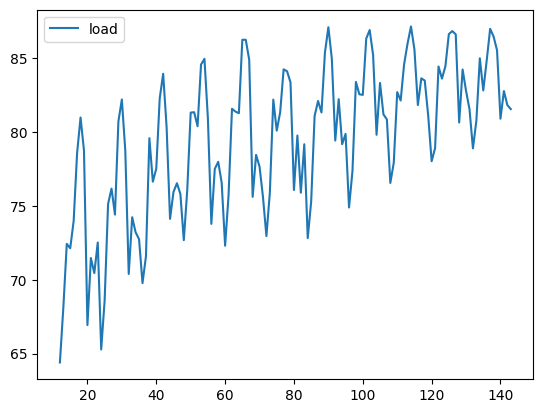

In [333]:
# Seasonal factors accounted for with new predictions included
df_airline.plot(kind='line', y='load')

After testing both MA and SES models and finding that the MA model performed better on the training data, we fit the model again and predicted for the final two months, resulting in a moving average prediction of 83.510214. When plotted as seen above, this forecast feels natural for where we see the data up to this point. We know the data is stationary from the AD Fuller test, so we know this type of prediction model is valid to use. Just from the eye test, it appears to be a reasonable suggestion that the load (with seasonal factors removed from the data) will stay around the 83-84 range rather than climb back down to the lower 70 range.

Looking at the graph with the seasonal factors scaled back in, the same more or less holds true. The little downward tail we added at the end seems to line up with the overall seasonal trends we see before and does not start into an unexpected pattern or shape. At least off initial impressions and the eye test (common sense tells us that going into the winter, bad weather and storms will cause a bit of a downward trend in plane load/demand/usage) we look like we are going in the right direction. We will just need to act based on the forecast, record the actual values and update our predictions going forward.